# Simulation Playground Notebook
This notebook is designed as a easy einterface to call the functions that we have defined

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import torch.optim as optim
import torch.nn as nn
import torch

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_participants_info, load_event_descriptions, load_behavioral_data, preprocess_data

# Data Preparation
Let's prepare some data first to fit our model. We are specifically using ["Locus coeruleus activity strengthens prioritized memories under arousal"](https://openneuro.org/datasets/ds002011/versions/1.0.0) dataset fror now.

In [2]:
DATASET_PATH = "data"
participants_df = load_participants_info(DATASET_PATH)
load_event_descriptions(DATASET_PATH)

df_behavior = load_behavioral_data(DATASET_PATH, "01")
for idx in range(2,11):
    sample_participant = f"0{idx}"
    df = load_behavioral_data(DATASET_PATH, sample_participant)
    df_behavior = pd.concat([df, df_behavior], ignore_index=True)

Let's preprocess our data first

In [3]:
X, Y, X_tensor, Y_tensor, scaler_X, scaler_Y, df_clean = preprocess_data(df_behavior)

X Shape: torch.Size([1699, 7]), Y Shape: torch.Size([1699])
Y Min: -1.0, Y Max: 1.0


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

# Training

In [5]:
from train import (train_feed_forward_nn,
                   train_vanilla_rnn,
                   train_vanilla_lstm,
                   train_vanilla_lc_model,
                   train_lstm_lc_model,
                   train_ff_controller,
                   train_ff_uncertain_controller
                   )
from analysis.evaluation import evaluate_model

## Fully Connected Neural Network

To illustrate our idea, we want to train 2 models from math and computer science, which is our vanilla feed forward networks and an recurrent networks.

Epoch 0, Loss: 0.11164763569831848
Epoch 100, Loss: 0.047789111733436584
Epoch 200, Loss: 0.046565908938646317
Epoch 300, Loss: 0.04581126198172569
Epoch 400, Loss: 0.04483966529369354
Epoch 500, Loss: 0.043953198939561844
Epoch 600, Loss: 0.04347057268023491
Epoch 700, Loss: 0.042557861655950546
Epoch 800, Loss: 0.04149555414915085
Epoch 900, Loss: 0.040801577270030975
Epoch 1000, Loss: 0.04058808088302612
Epoch 1100, Loss: 0.0401359386742115
Epoch 1200, Loss: 0.039408810436725616
Epoch 1300, Loss: 0.03961044177412987
Epoch 1400, Loss: 0.03876537084579468
Epoch 1500, Loss: 0.03898001089692116
Epoch 1600, Loss: 0.038076892495155334
Epoch 1700, Loss: 0.03800181671977043
Epoch 1800, Loss: 0.03822709247469902
Epoch 1900, Loss: 0.037563592195510864
Training complete!
Evaluating Model: FeedForwardNN


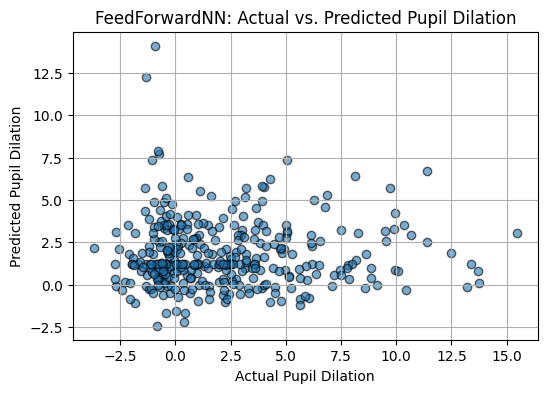

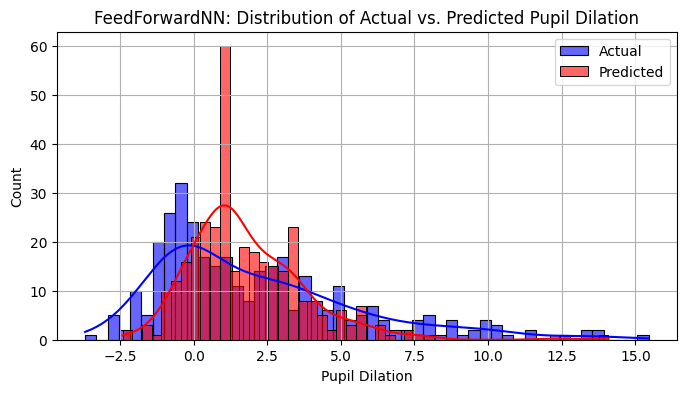

FeedForwardNN - Pearson Correlation: 0.0065


In [6]:
model_ff = train_feed_forward_nn(X_train, Y_train,epochs=2000)
evaluate_model(model_ff, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Recurent Neural Networks

We will  do the same thing with an recurrent neural network

In [7]:
# model_rnn = train_vanilla_rnn(X_train, Y_train, epochs=2000)
# evaluate_model(model_rnn, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM Models

In [8]:
# model_lstm = train_vanilla_lstm(X_train, Y_train, epochs=5000, hidden_dim=12)
# evaluate_model(model_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LCNECortex Fitter Model

Now coming to our customized LCNECortex model

In [9]:
# model_lc_vanilla = train_vanilla_lc_model(X_train, Y_train, epochs=2000)
# evaluate_model(model_lc_vanilla, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM LCNECortex Model

In [10]:
# model_lc_lstm = train_lstm_lc_model(X_train, Y_train, epochs=2000, hidden_dim=64)
# evaluate_model(model_lc_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# FF Gadget Model

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0, Loss: 0.070033
Epoch 100, Loss: 0.026530
Epoch 200, Loss: 0.026372
Epoch 300, Loss: 0.024802
Early stopping triggered at epoch 310
Training complete!
Evaluating Model: FFGadgetController


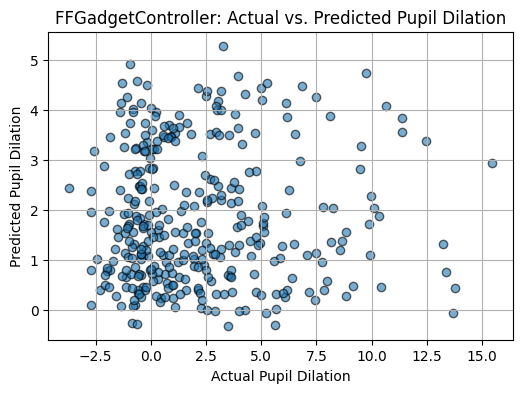

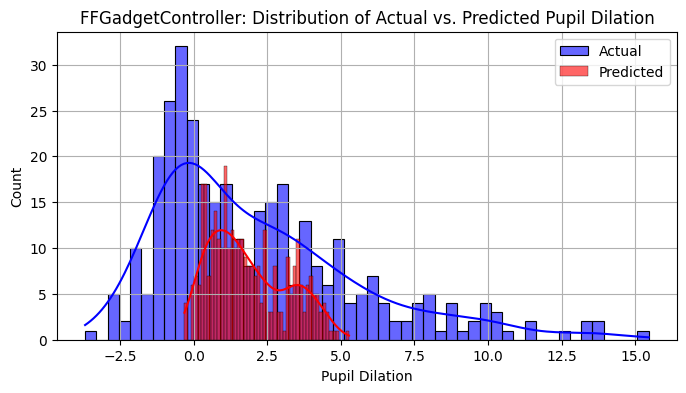

FFGadgetController - Pearson Correlation: 0.0231


In [11]:
ff_gadget = train_ff_controller(X_train, Y_train, epochs=5000, hidden_dim=1024, patience=200)
evaluate_model(ff_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Modified Uncertainty GadgetModel

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0, Loss: 1.002536
Epoch 100, Loss: 0.051261
Epoch 200, Loss: 0.049489
Epoch 300, Loss: 0.050455
Epoch 400, Loss: 0.056188
Epoch 500, Loss: 0.056328
Epoch 600, Loss: 0.052878
Epoch 700, Loss: 0.042931
Epoch 800, Loss: 0.049264
Early stopping triggered at epoch 855
Training complete!


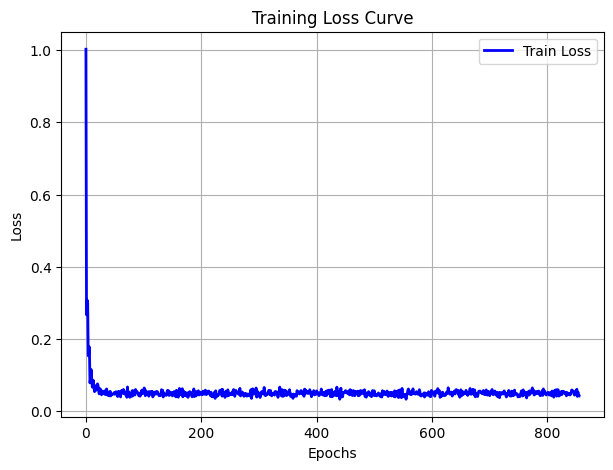

Evaluating Model: FFGadgetUncertainController


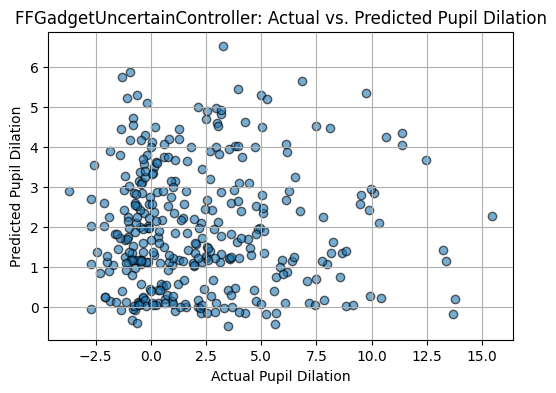

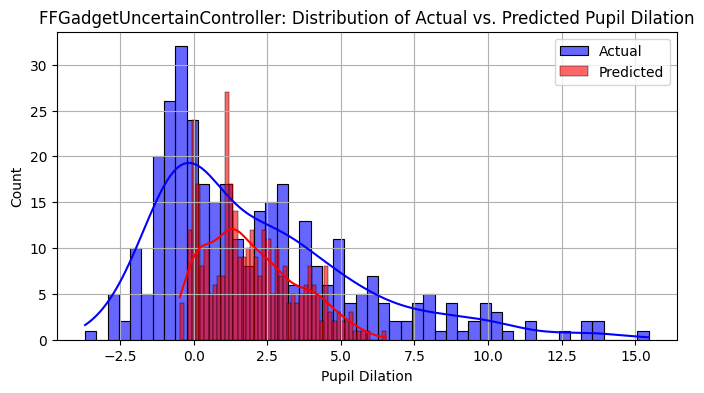

FFGadgetUncertainController - Pearson Correlation: 0.0194


In [26]:
ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=1000, hidden_dim=256, batch_size=256, patience=300)
evaluate_model(ff_uncertain_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# Analysis

In [13]:
from analysis.analysis import (pca_lcne_lstm,
                               pca_feed_forward,
                               pca_lcne,
                               pca_lstm,
                               analyze_ff_gadget_activations,
                               evaluate_ff_uncertainty_gadget
)

## Feed-Forward Neural Networks

In [14]:
# pca_feed_forward(model_ff, X_tensor, df_behavior)

## LCNECortex Model

We will see that, though  under fitted with the real data, there are some structureness to the data that we can play around with since we injected mechanistic insights into it.

In [15]:
# with torch.no_grad():
#     prev_LC = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)
#     prev_Cortex = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)

#     LC_act, NE_act, C_act, Pupil_pred, LC_raw, NE_raw, C_raw = model_lc_vanilla(X_tensor, prev_LC, prev_Cortex, return_activations=True)

# act_lc = LC_act.cpu().numpy()
# act_ne = NE_act.cpu().numpy()
# act_cortex = C_act.cpu().numpy()

# df_activations = pd.DataFrame({
#     'LC_Mean': act_lc.mean(axis=1),
#     'NE_Mean': act_ne.mean(axis=1),
#     'Cortex_Mean': act_cortex.mean(axis=1),
#     'PupilPred': Pupil_pred.cpu().numpy().squeeze(),
#     'ActualPupil': df_clean['Event_PupilDilation'].values  # Ensure this aligns with X_tensor
# })

# plt.figure(figsize=(12, 4))

# plt.subplot(1, 3, 1)
# sns.histplot(df_activations['LC_Mean'], kde=True, bins=50, color='blue')
# plt.title("LC Activation Distribution")

# plt.subplot(1, 3, 2)
# sns.histplot(df_activations['NE_Mean'], kde=True, bins=50, color='green')
# plt.title("NE Activation Distribution")

# plt.subplot(1, 3, 3)
# sns.histplot(df_activations['Cortex_Mean'], kde=True, bins=50, color='red')
# plt.title("Cortex Activation Distribution")

In [16]:
# pca_lcne(model_lc_vanilla, X_tensor, df_clean)

## LSTM LCNECortex Model

In [17]:
# pca_lcne_lstm(model_lc_lstm, X_tensor, df_clean)

## Vanilla LSTM Comparison

In [18]:
# pca_lstm(model_lstm, X_test, df_clean)

## FF Gadget Model

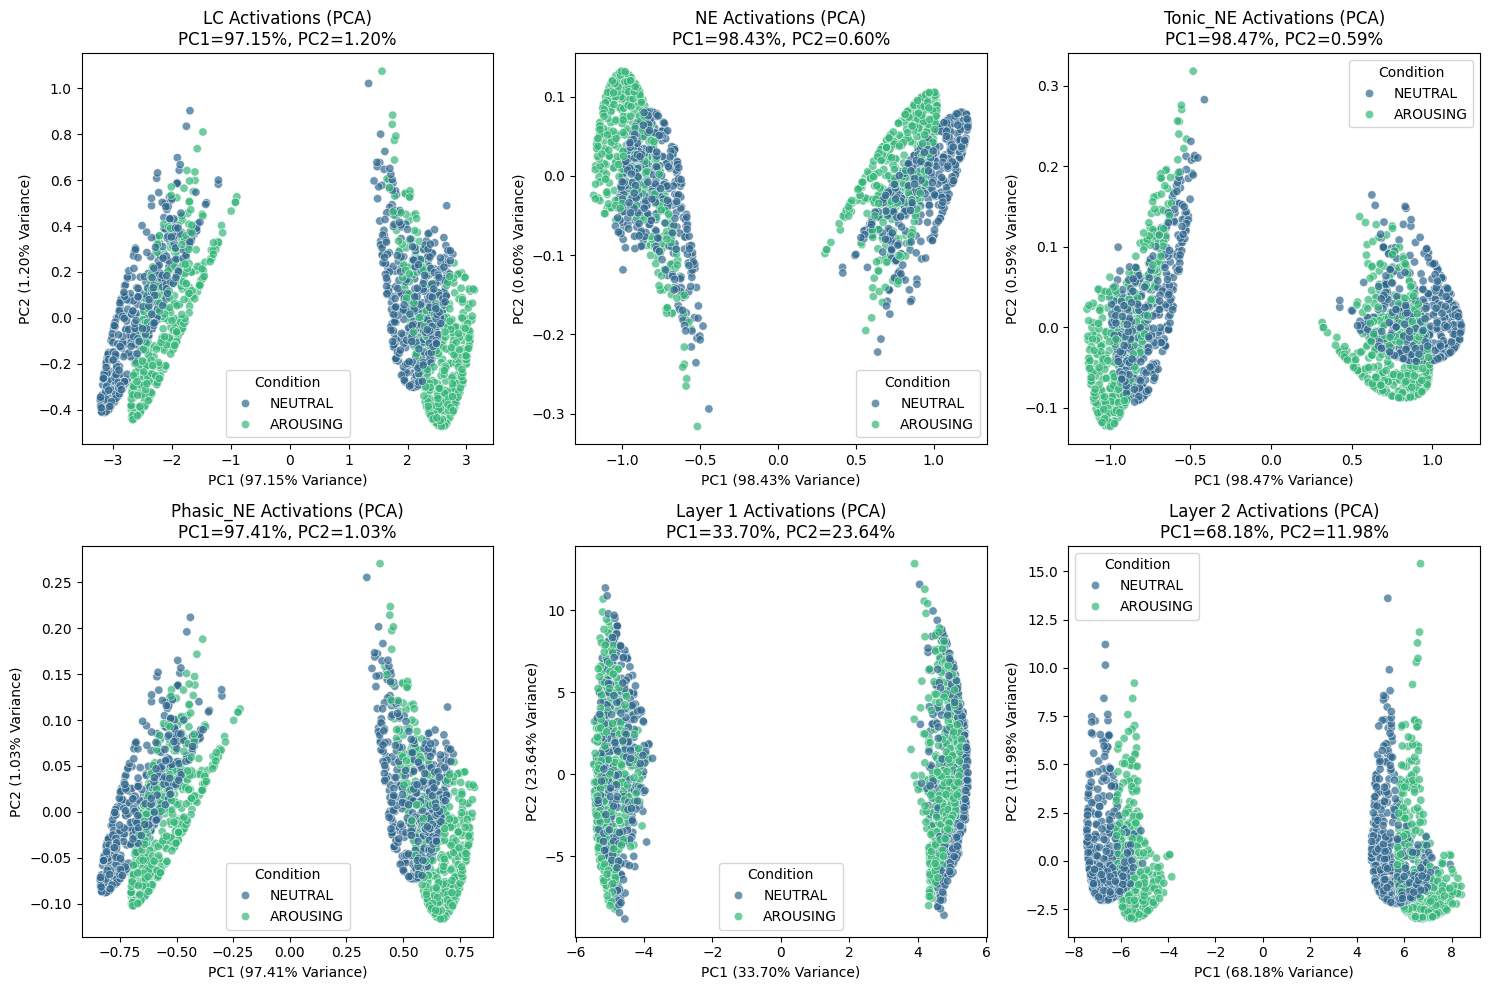

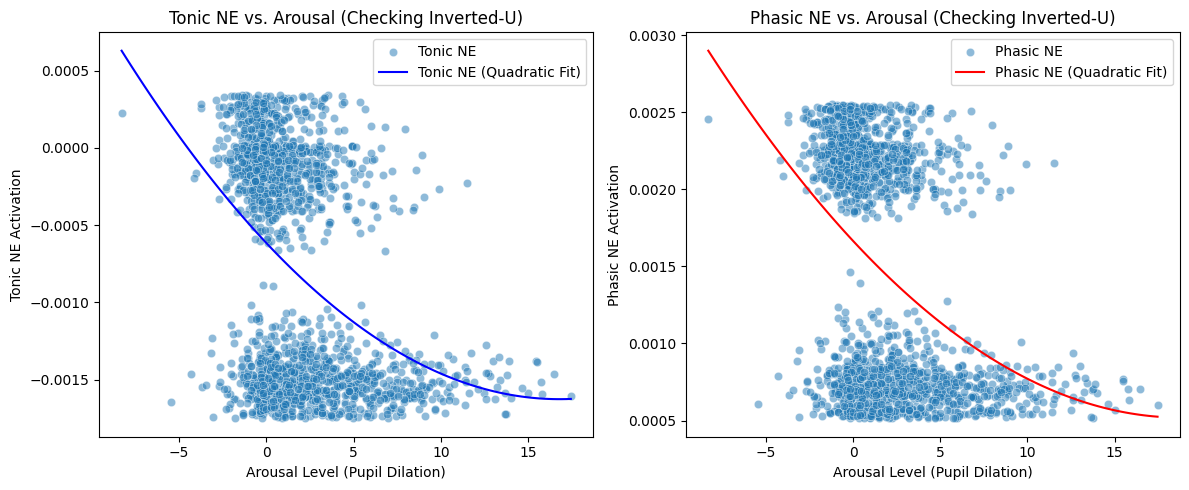


 Pearson Correlation with Actual Pupil Dilation:
LC: 0.407
NE: 0.398
Tonic_NE: -0.400
Phasic_NE: -0.402
Layer 1: 0.007
Layer 2: 0.139
Predicted Pupil Dilation: 0.454


In [19]:
analyze_ff_gadget_activations(ff_gadget, X_tensor, df_clean)

This model elarning representation is quite unstable

## Modified Uncertainty GadgetModel

Pupil Dilation MAE: 2.1635
Pupil Dilation MSE: 8.1510


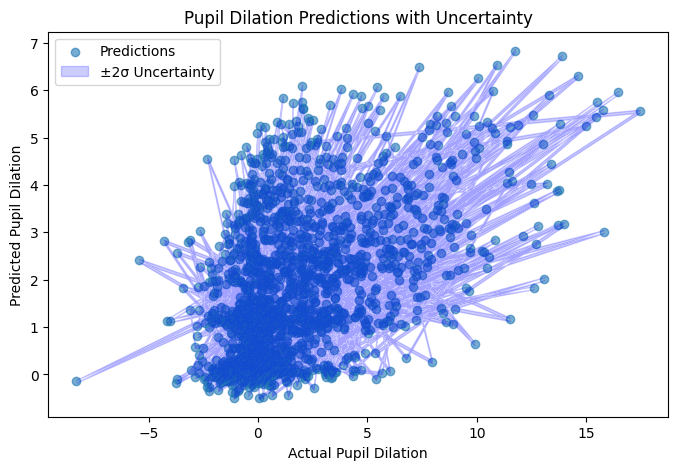

In [27]:
evaluate_ff_uncertainty_gadget(ff_uncertain_gadget, X_tensor, Y_tensor, scaler_Y)

In [33]:
from analysis.analysis import (extract_activations_gadget,
                               compute_mapper_graph,
                               compute_persistent_homology)

Persistent homology seems to work with the `uncertainty` model but not other models.

Analyzing LC activations...


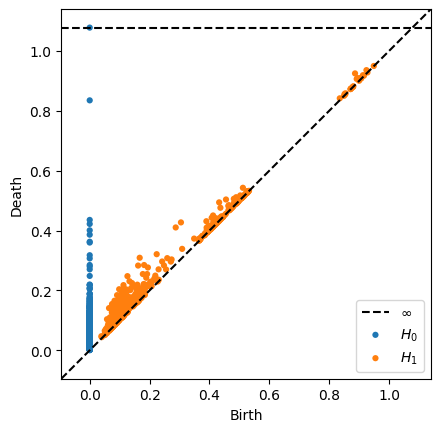

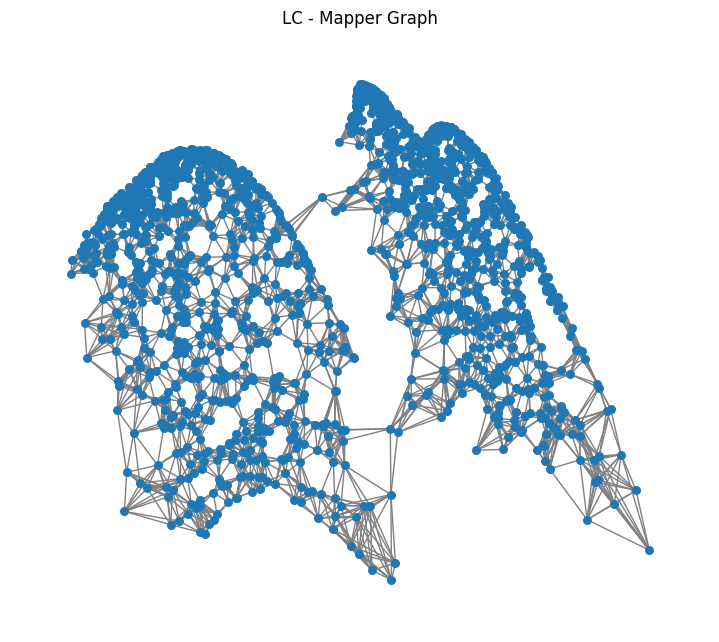

Analyzing NE activations...


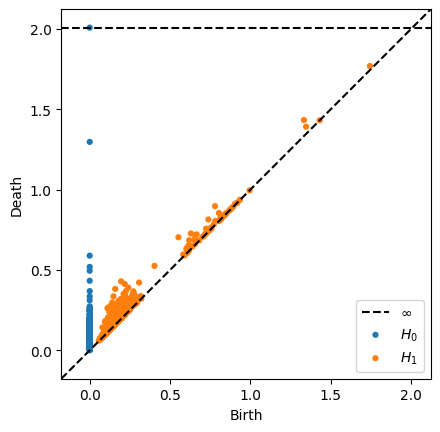

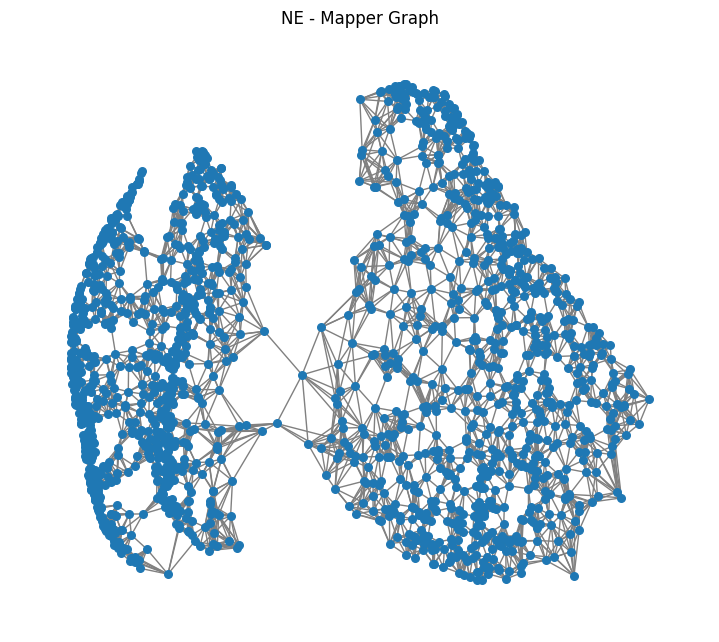

Analyzing Tonic_NE activations...


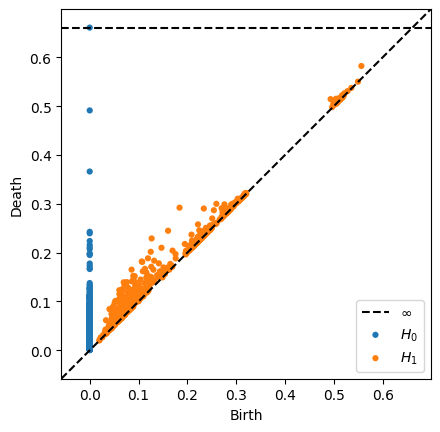

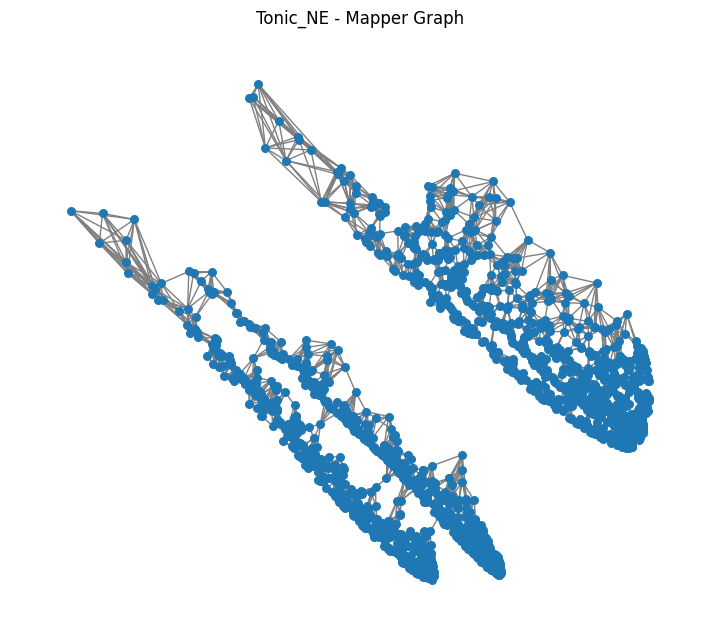

Analyzing Phasic_NE activations...


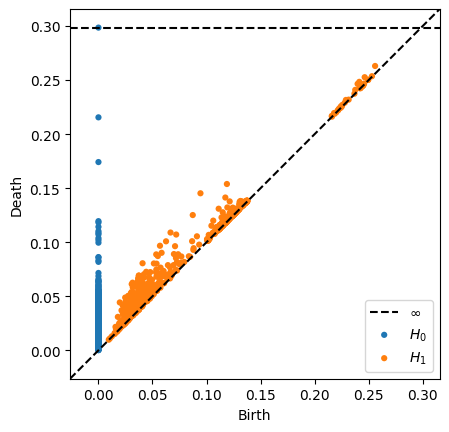

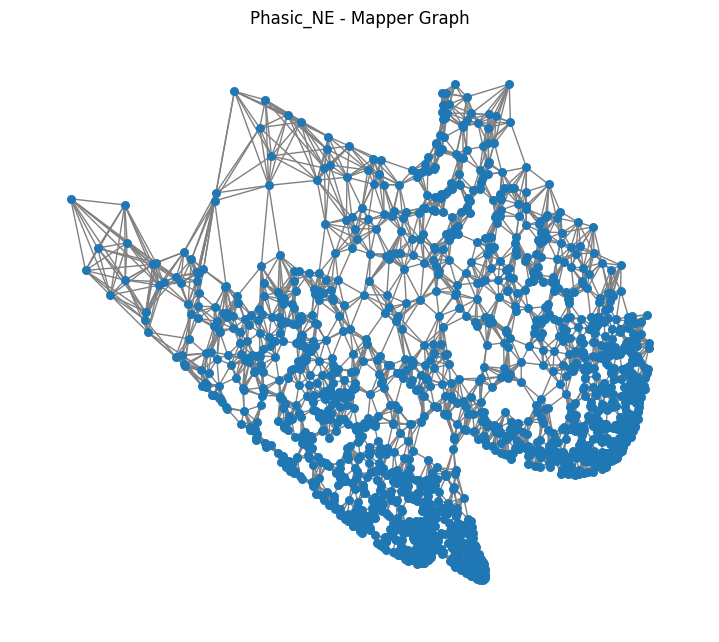

Analyzing Hidden_1 activations...


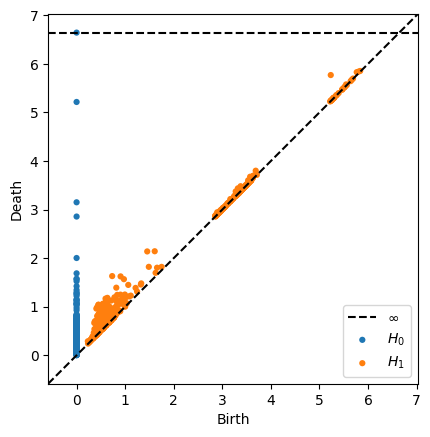

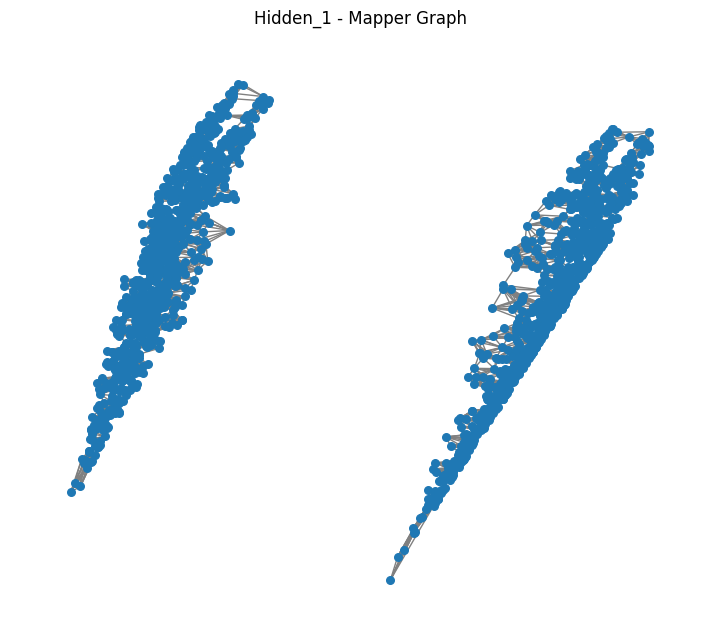

Analyzing Hidden_2 activations...


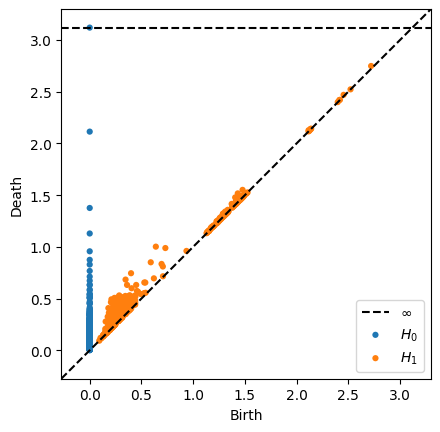

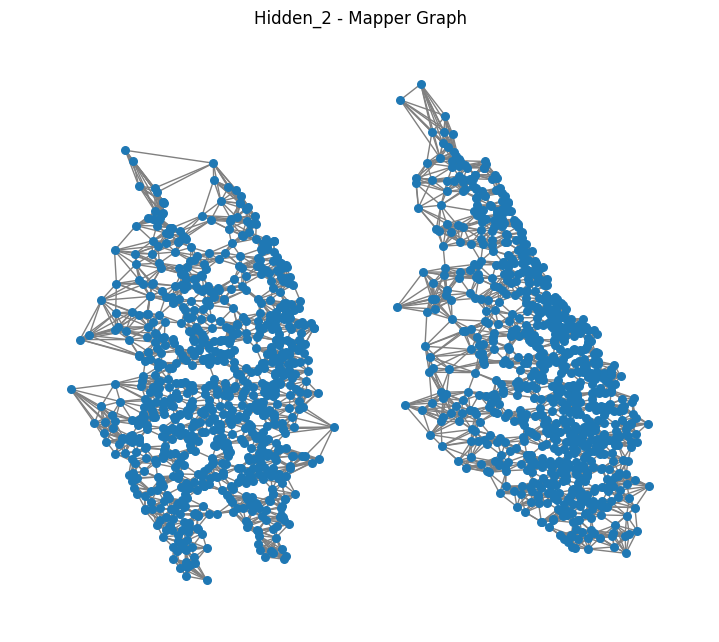

In [34]:
activations = extract_activations_gadget(ff_uncertain_gadget, X_tensor)
# activations = extract_activations_ff_uncertain_gadget(ff_gadget, X_tensor)

for key, act in activations.items():
    print(f"Analyzing {key} activations...")
    compute_persistent_homology(act, title=f"{key} - Persistent Homology")
    compute_mapper_graph(act, title=f"{key} - Mapper Graph")